# RetainIQ — Phase 4.4: Model Evaluation, Feature Interpretation & Findings

## Objective

I interpret the model results and connect predicted churn risk back to customer-level business data.

I will examine:

- model performance
- Logistic Regression coefficients
- Random Forest feature importance
- classification errors
- churn probability bands
- high-risk customer profiles
- revenue at risk
- modeling limitations

## 1. Connect to MySQL and Rebuild the Modeling Population

In [15]:
from pathlib import Path
from getpass import getpass
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

MYSQL_CONFIG = {
    "host": "localhost",
    "port": 3306,
    "user": "retainiq_user",
    "password": getpass("Enter MySQL password for retainiq_user: "),
    "database": "retainiq"
}

connection = mysql.connector.connect(**MYSQL_CONFIG)

query = '''
SELECT
    f.customer_id,
    f.tenure_months,
    f.monthly_charge,
    f.total_charges,
    f.total_refunds,
    f.total_revenue,
    f.satisfaction_score,
    f.cltv,
    d.gender,
    d.age,
    d.under_30,
    d.senior_citizen,
    d.married,
    d.dependents,
    d.number_of_dependents,
    a.quarter,
    a.referred_a_friend,
    a.number_of_referrals,
    a.offer,
    a.contract,
    a.paperless_billing,
    a.payment_method,
    a.total_extra_data_charges,
    a.total_long_distance_charges,
    s.phone_service,
    s.multiple_lines,
    s.internet_service,
    s.internet_type,
    s.online_security,
    s.online_backup,
    s.device_protection_plan,
    s.premium_tech_support,
    s.streaming_tv,
    s.streaming_movies,
    s.streaming_music,
    s.unlimited_data,
    s.avg_monthly_long_distance_charges,
    s.avg_monthly_gb_download,
    f.churn_label
FROM fact_customer_status f
JOIN dim_demographics d ON f.customer_id = d.customer_id
JOIN dim_account a ON f.customer_id = a.customer_id
JOIN dim_services s ON f.customer_id = s.customer_id
WHERE f.customer_status IN ('Stayed', 'Churned');
'''

model_df = pd.read_sql(query, connection)
connection.close()

model_df["target"] = (model_df["churn_label"] == "Yes").astype(int)

X = model_df.drop(columns=["customer_id", "churn_label", "target"])
y = model_df["target"]

numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

C:\Users\Sahil\AppData\Local\Temp\ipykernel_3608\3692931080.py:75: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  model_df = pd.read_sql(query, connection)


## 2. Fit Logistic Regression

In [2]:
logistic_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

logistic_model = Pipeline([
    ("preprocessor", logistic_preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

## 3. Fit Random Forest

In [3]:
rf_preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

rf_model = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

## 4. Final Model Comparison

In [4]:
final_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC AUC": [roc_auc_score(y_test, logistic_prob), roc_auc_score(y_test, rf_prob)],
    "Precision": [precision_score(y_test, logistic_pred), precision_score(y_test, rf_pred)],
    "Recall": [recall_score(y_test, logistic_pred), recall_score(y_test, rf_pred)],
    "F1": [f1_score(y_test, logistic_pred), f1_score(y_test, rf_pred)]
}).round(3)

final_comparison

,Model,ROC AUC,Precision,Recall,F1
0,Logistic Regression,0.994,0.881,0.955,0.917
1,Random Forest,0.992,0.974,0.909,0.941


## 5. Logistic Regression Coefficients

In [5]:
feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = logistic_model.named_steps["model"].coef_[0]

logistic_coefficients = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })
    .sort_values("coefficient", ascending=False)
)

logistic_coefficients.head(20)

,feature,coefficient
51,categorical__online_security_No,1.377612
22,categorical__dependents_No,0.846188
28,categorical__offer_Offer A,0.782855
33,categorical__contract_Month-to-Month,0.634126
32,categorical__offer_Offer E,0.632729
1,numeric__monthly_charge,0.575740
26,categorical__referred_a_friend_Yes,0.566993
2,numeric__total_charges,0.261769
4,numeric__total_revenue,0.258915
19,categorical__senior_citizen_Yes,0.182511


## 6. Negative Logistic Coefficients

In [6]:
logistic_coefficients.tail(20).sort_values("coefficient")

,feature,coefficient
5,numeric__satisfaction_score,-6.830957
9,numeric__number_of_referrals,-1.815080
52,categorical__online_security_Yes,-1.694357
0,numeric__tenure_months,-1.263454
23,categorical__dependents_Yes,-1.162933
35,categorical__contract_Two Year,-0.902749
25,categorical__referred_a_friend_No,-0.883737
31,categorical__offer_Offer D,-0.842868
30,categorical__offer_Offer C,-0.565086
18,categorical__senior_citizen_No,-0.499255


## 7. Random Forest Feature Importance

In [7]:
rf_feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
rf_importance = (
    pd.DataFrame({
        "feature": rf_feature_names,
        "importance": rf_model.named_steps["model"].feature_importances_
    })
    .sort_values("importance", ascending=False)
)

rf_importance.head(20)

,feature,importance
5,numeric__satisfaction_score,0.359395
0,numeric__tenure_months,0.076489
33,categorical__contract_Month-to-Month,0.076227
9,numeric__number_of_referrals,0.044925
2,numeric__total_charges,0.044632
35,categorical__contract_Two Year,0.043778
4,numeric__total_revenue,0.041679
11,numeric__total_long_distance_charges,0.027070
1,numeric__monthly_charge,0.026121
49,categorical__internet_type_Fiber Optic,0.019091


## 8. Visualize Top Features

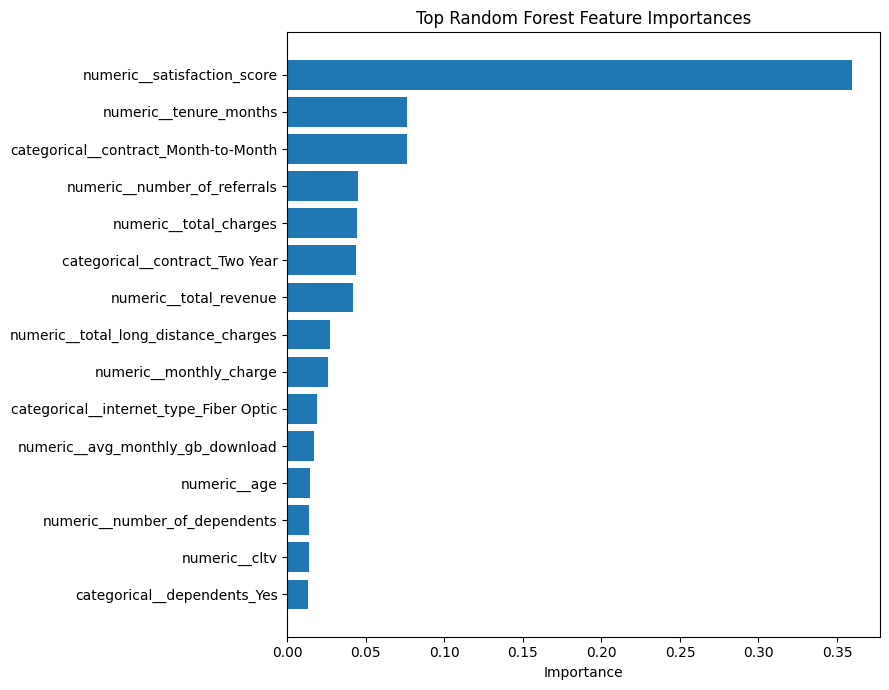

In [8]:
top_features = rf_importance.head(15).sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_features["feature"], top_features["importance"])
ax.set_title("Top Random Forest Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 9. Error Analysis

In [9]:
cm = confusion_matrix(y_test, rf_pred)
tn, fp, fn, tp = cm.ravel()

error_summary = pd.DataFrame({
    "Outcome": ["True Negative", "False Positive", "False Negative", "True Positive"],
    "Count": [tn, fp, fn, tp]
})

error_summary

,Outcome,Count
0,True Negative,935
1,False Positive,9
2,False Negative,34
3,True Positive,340


I pay particular attention to false negatives because they represent churners that I failed to
identify.

I also track false positives because an overly broad intervention list could reduce the efficiency
of a retention team.

## 10. Create Churn Probability Bands

In [10]:
risk = model_df.loc[
    X_test.index,
    ["customer_id", "churn_label"]
].copy()

risk["predicted_churn_probability"] = rf_prob
risk["predicted_churn"] = rf_pred

risk["risk_band"] = pd.cut(
    risk["predicted_churn_probability"],
    bins=[-0.01, 0.30, 0.60, 0.80, 1.00],
    labels=["Low", "Moderate", "High", "Very High"]
)

risk.head()

,customer_id,churn_label,predicted_churn_probability,predicted_churn,risk_band
3922,5924-IFQTT,No,0.043344,0,Low
5312,8000-REIQB,Yes,1.000000,1,Very High
2108,3243-ZHOHY,No,0.047481,0,Low
5850,8849-AYPTR,No,0.193024,0,Low
1704,2659-VXMWZ,Yes,0.156584,0,Low


## 11. Risk-Band Summary

In [11]:
risk_band_summary = (
    risk.groupby("risk_band", observed=False)
    .size()
    .rename("customers")
    .reset_index()
)

risk_band_summary["percentage"] = (
    risk_band_summary["customers"] / len(risk) * 100
).round(2)

risk_band_summary

,risk_band,customers,percentage
0,Low,933,70.79
1,Moderate,44,3.34
2,High,55,4.17
3,Very High,286,21.70


## 12. Enrich High-Risk Customers From MySQL

In [12]:
connection = mysql.connector.connect(**MYSQL_CONFIG)

detail_query = '''
SELECT
    f.customer_id,
    f.cltv,
    f.total_revenue,
    f.monthly_charge,
    f.satisfaction_score,
    f.churn_score,
    a.contract,
    a.offer,
    a.payment_method,
    s.internet_type,
    s.premium_tech_support
FROM fact_customer_status f
JOIN dim_account a ON f.customer_id = a.customer_id
JOIN dim_services s ON f.customer_id = s.customer_id;
'''

details = pd.read_sql(detail_query, connection)
connection.close()

risk_enriched = risk.merge(details, on="customer_id", how="left")

high_risk = (
    risk_enriched[
        risk_enriched["risk_band"].isin(["High", "Very High"])
    ]
    .sort_values("predicted_churn_probability", ascending=False)
)

high_risk.head(25)

C:\Users\Sahil\AppData\Local\Temp\ipykernel_3608\2664300814.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  details = pd.read_sql(detail_query, connection)


,customer_id,churn_label,predicted_churn_probability,predicted_churn,risk_band,cltv,total_revenue,monthly_charge,satisfaction_score,churn_score,contract,offer,payment_method,internet_type,premium_tech_support
1,8000-REIQB,Yes,1.000000,1,Very High,3208,102.45,69.95,2,94,Month-to-Month,Offer E,Bank Withdrawal,Fiber Optic,No
631,7594-RQHXR,Yes,1.000000,1,Very High,3108,101.32,79.60,2,94,Month-to-Month,Offer E,Bank Withdrawal,Fiber Optic,No
1081,3244-DCJWY,Yes,1.000000,1,Very High,4133,93.25,70.25,1,89,Month-to-Month,Offer E,Bank Withdrawal,Fiber Optic,No
981,8945-GRKHX,Yes,1.000000,1,Very High,2728,124.74,78.65,1,81,Month-to-Month,Offer E,Bank Withdrawal,Fiber Optic,No
998,3722-WPXTK,Yes,1.000000,1,Very High,4254,102.61,88.35,1,72,Month-to-Month,No Offer,Bank Withdrawal,Fiber Optic,No
961,4550-EVXNY,Yes,1.000000,1,Very High,2418,118.89,69.65,2,77,Month-to-Month,Offer E,Bank Withdrawal,Fiber Optic,No
159,5597-GLBUC,Yes,1.000000,1,Very High,4931,108.42,85.45,2,95,Month-to-Month,Offer E,Bank Withdrawal,Fiber Optic,No
698,9804-ICWBG,Yes,1.000000,1,Very High,3349,115.40,69.90,2,88,Month-to-Month,No Offer,Bank Withdrawal,Fiber Optic,No
760,3877-JRJIP,Yes,1.000000,1,Very High,4017,81.90,59.85,2,71,Month-to-Month,No Offer,Bank Withdrawal,Cable,No
665,4317-VTEOA,Yes,1.000000,1,Very High,5355,93.78,50.75,2,93,Month-to-Month,Offer E,Bank Withdrawal,DSL,No


## 13. Revenue in the High-Risk Group

In [13]:
pd.Series({
    "high_risk_customers": len(high_risk),
    "recorded_revenue_in_high_risk_group": high_risk["total_revenue"].sum()
})

high_risk_customers                       341.00
recorded_revenue_in_high_risk_group    606782.16
dtype: float64

## 14. Export Phase 4 Outputs

In [16]:
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

risk_enriched.to_csv(
    output_dir / "customer_churn_risk_scores.csv",
    index=False
)

final_comparison.to_csv(
    output_dir / "model_comparison.csv",
    index=False
)

rf_importance.to_csv(
    output_dir / "random_forest_feature_importance.csv",
    index=False
)

print("Saved Phase 4 model outputs.")

Saved Phase 4 model outputs.


## 15. Model Limitations

I document the following limitations:

- this is a historical static dataset
- no temporal holdout is available
- `churn_score` and `CLTV` require leakage review
- model probabilities are not automatically calibrated
- statistical association does not prove causation
- production performance would require monitoring and retraining
- retention interventions should be tested with business experiments

# Phase 4 Final Conclusion

I completed the EDA and statistical modeling layer.

I now have:

- MySQL-backed EDA
- churn population definition
- formal numeric and categorical tests
- Logistic Regression
- Random Forest
- cross-validation
- ROC and precision-recall evaluation
- model interpretation
- error analysis
- churn probability bands
- customer risk output
- revenue-at-risk analysis

**Next:** Phase 5 — Customer Segmentation & Retention Profiling.